# E-Commerce Orders — Exploratory Data Analysis
### Project 2 | DecodeLabs Data Analytics Internship

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set_style("whitegrid")

In [2]:
df = pd.read_excel("Project1_Data_Cleaning_SujalSinghNegi.xlsx")

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 1. Descriptive Statistics

In [4]:
df[['Quantity' , 'UnitPrice' , 'TotalPrice']].describe().round(2)

,Quantity,UnitPrice,TotalPrice
count,1200.00,1200.00,1200.00
mean,2.95,356.41,1053.97
std,1.41,197.18,819.86
min,1.00,11.39,11.39
25%,2.00,186.06,410.52
50%,3.00,364.21,823.62
75%,4.00,521.57,1578.48
max,5.00,699.93,3456.40


In [5]:
df["TotalPrice"].count()

np.int64(1200)

In [6]:
median_val = df["TotalPrice"].median()

In [7]:
mean_val = df["TotalPrice"].mean()

## 2. Distribution & Outliers

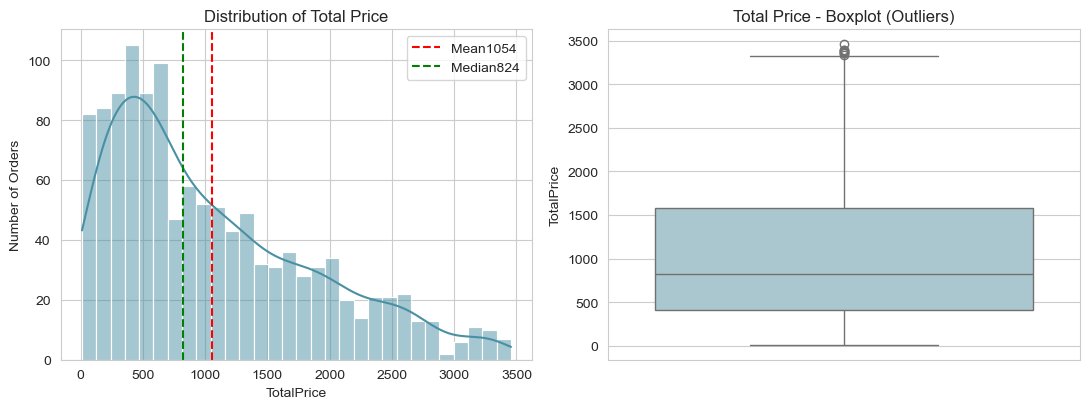

In [8]:
fig , axes = plt.subplots(1,2 , figsize = (11,4.2))
sns.histplot(df['TotalPrice'],bins=30 ,kde=True ,color="#4a90a4" , ax = axes[0])
axes[0].axvline(mean_val , color = "red" , linestyle = "--" , label = f"Mean{mean_val :.0f}")
axes[0].axvline(median_val , color = "green" , linestyle = "--" , label = f"Median{median_val :.0f}")
axes[0].set_title("Distribution of Total Price")
axes[0].legend()
axes[0].set_ylabel("Number of Orders")

sns.boxplot(y = df['TotalPrice'] , ax =axes[1] , color="#a4c9d4" )
axes[1].set_title("Total Price - Boxplot (Outliers)")
plt.tight_layout()
plt.show()


### IQR Method — Detecting Outliers Precisely

In [9]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[((df['TotalPrice'] < lower_limit ) | (df['TotalPrice'] > upper_limit))]
print(f"Q1 = {Q1} , Q3 = {Q3} , IQR = {IQR}")
print(f"Normal range: {lower_limit:.2f} to {upper_limit:.2f}")
print(f"Total outliers found: {len(outliers)}")
outliers

Q1 = 410.52 , Q3 = 1578.475 , IQR = 1167.955
Normal range: -1341.41 to 3330.41
Total outliers found: 8


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No Coupon,Facebook,3390.95



## 3. Monthly Trend

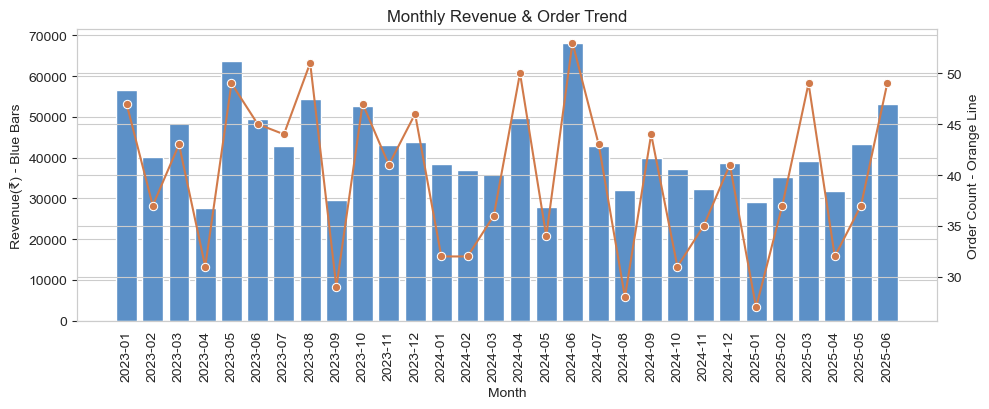

In [10]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly = df.groupby('Month').agg(
    Orders = ('OrderID' , 'count') ,
    Revenue = ('TotalPrice' , 'sum')
)
fig , ax1 = plt.subplots(figsize = (10 , 4.2)) 
sns.barplot(data = monthly , x = 'Month' , y = 'Revenue' , ax=ax1 , color="#4a90d9")
ax1.set_ylabel("Revenue(₹) - Blue Bars")
ax1.set_xlabel("Month")
ax1.tick_params(axis = 'x' , rotation = 90)

ax2 = ax1.twinx()
sns.lineplot(data = monthly , x = 'Month' , y = 'Orders' , color = "#d17a4a" , marker="o",  ax = ax2)
ax2.set_ylabel("Order Count - Orange Line")
ax1.set_title("Monthly Revenue & Order Trend")
plt.tight_layout()
plt.show()



## 4. Category-wise Breakdown

### Revenue by Product

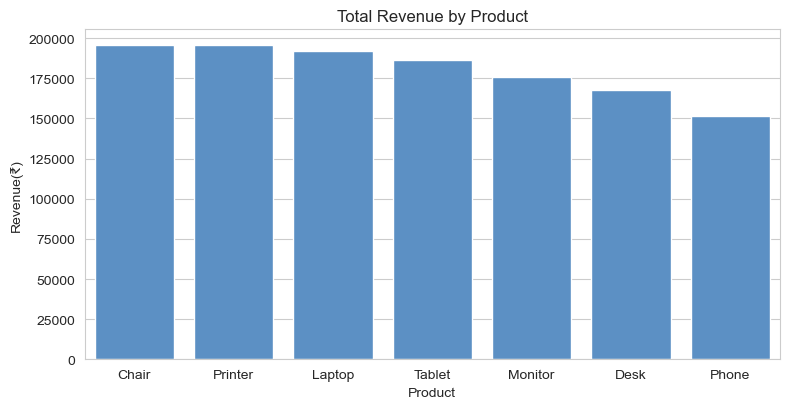

In [11]:
prod = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
plt.figure(figsize= (8 , 4.2))
sns.barplot(data=prod , color = "#4a90d6" )
plt.title("Total Revenue by Product")
plt.ylabel("Revenue(₹)")
plt.tight_layout()
plt.show()

In [20]:
top_product = prod.idxmax()       
top_value = prod.max()               
low_product = prod.idxmin()       
low_value = prod.min() 
print(f"Top product: {top_product}, Revenue: ₹{top_value:,.2f}")
print(f"low product: {low_product}, Revenue: ₹{low_value:,.2f}")

Top product: Chair, Revenue: ₹195,620.11
low product: Phone, Revenue: ₹151,722.39


### Revenue & Orders by Payment Method

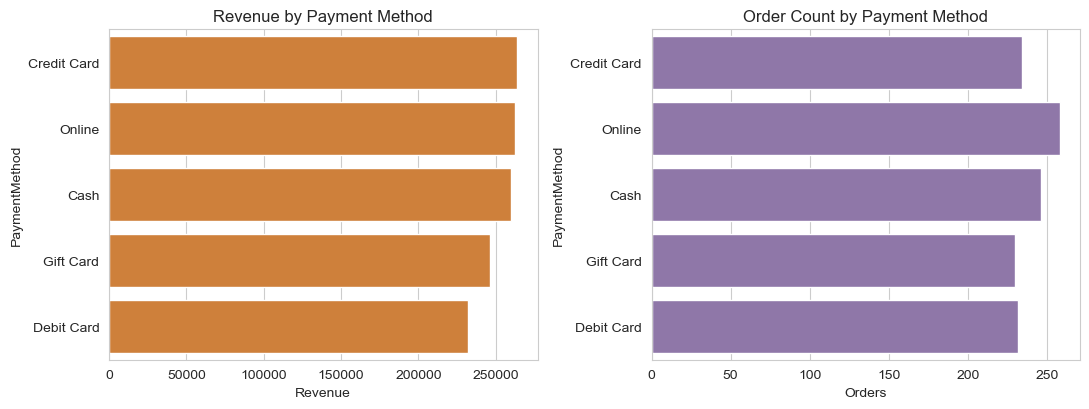

In [12]:
pm = df.groupby('PaymentMethod').agg(
     Orders = ('OrderID' , 'count') ,
    Revenue = ('TotalPrice' , 'sum')
).reset_index().sort_values(by = 'Revenue' , ascending = False)

fig , axes = plt.subplots(1,2, figsize = (11 , 4.2))
sns.barplot(data = pm , y = 'PaymentMethod' , x ='Revenue' , ax=axes[0] , color = "#e67e22")
axes[0].set_title("Revenue by Payment Method")
sns.barplot(data = pm , y = 'PaymentMethod' , x ='Orders' , ax=axes[1] , color = "#8f6fb0" )
axes[1].set_title("Order Count by Payment Method")
plt.tight_layout()
plt.show()

### Revenue by Referral Source

Text(0.5, 0, 'Revenue(₹)')

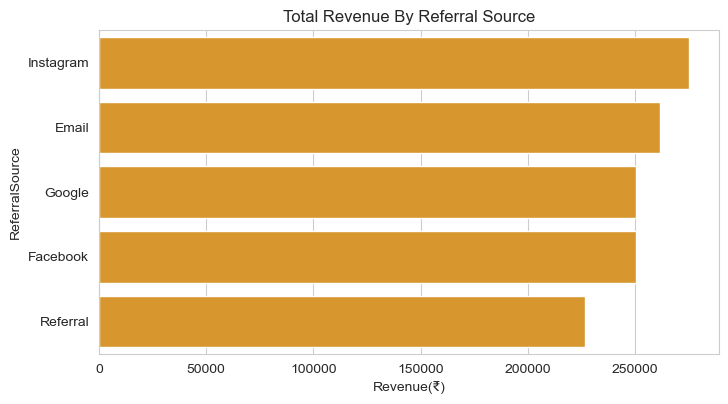

In [13]:
ref = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8 , 4.2))
sns.barplot(data=ref , y = 'ReferralSource' , x = 'TotalPrice',color=("#f39c12"))
plt.title("Total Revenue By Referral Source")
plt.xlabel("Revenue(₹)")


## 5. Correlation Analysis

Correlation between Quantity and TotalPrice : 0.62


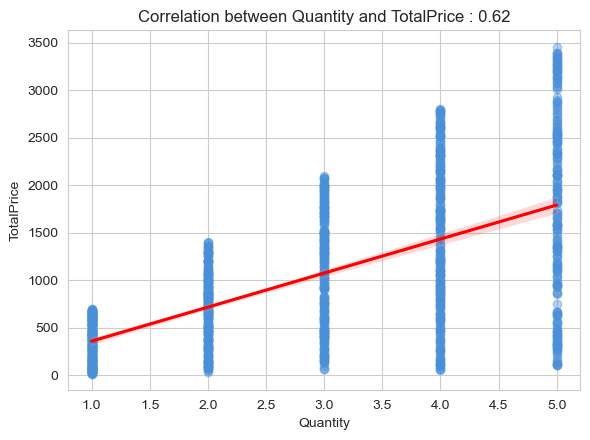

In [14]:
corr = df['Quantity'].corr(df['TotalPrice'])
print(f"Correlation between Quantity and TotalPrice : {corr :.2f}")
plt.figure (figsize=(6,4.5))
sns.regplot(data= df  , x='Quantity' , y ='TotalPrice' , scatter_kws={"alpha":0.4 , "color":"#4a90d9"}
           ,line_kws={"color":"red"})
plt.title(f"Correlation between Quantity and TotalPrice : {corr :.2f}")
plt.tight_layout()
plt.show()

## Key Findings

1. **Right-skewed distribution**: The mean order value (₹1,054) is higher than the median (₹824), 
   indicating that a few high-value orders are pulling the average upward. The median is a more 
   reliable measure of central tendency for this dataset.

2. **8 outliers detected via IQR method**: All outliers are high-value bulk orders (Quantity=5, 
   high-UnitPrice products like Laptops and Printers). These are genuine purchases rather than 
   data errors, so they were retained rather than removed.

3. **Peak revenue month was 2024-06 (~₹68,068.54)**, while January (both 2024 and 2025) showed a 
   dip in sales. No strong seasonal cycle was observed overall, but January consistently 
   underperforms slightly.

4. **Chair generates the highest revenue (₹195,620.11)** , while ** Phone generates the least 
   (₹151,722.39** ) — product strategy and inventory planning could focus around the 
   top-performing items.

5. **Credit Card is the most frequently used payment method**, and **Online** 
   is the most common order status .

6. **Quantity and TotalPrice show a moderate-to-strong positive correlation (r = 0.62)** — this is 
   expected since TotalPrice is directly derived from Quantity. Encouraging bulk purchases could 
   be an effective lever for increasing overall revenue.